<div style="text-align:center; padding: 22px 28px 10px 28px; font-family: 'Segoe UI', sans-serif; color:#113A5C;">
  
  <div style="display:inline-block; padding: 10px 18px; border-radius: 999px; background: linear-gradient(90deg, #EAF2FB, #EEF8E7); font-size: 14px; letter-spacing: 0.08em; text-transform: uppercase; color:#004E9A; font-weight:600;">
    INFB8090 - Computacion Paralela
  </div>
  <h1 style="margin: 18px 0 8px 0; font-size: 34px; color:#004E9A;">Laboratorio 2: Modelos y metricas de desempeno</h1>
  <p style="max-width: 920px; margin: 0 auto 16px auto; font-size: 16px; line-height: 1.65; color:#24435B;">
    Notebook experimental con ejercicios originales sobre vectorizacion, paralelismo de tareas y procesamiento por lotes.
    El objetivo es medir, comparar e interpretar resultados con base en speedup, eficiencia, overhead y criterio de seleccion de modelo.
  </p>
  <div style="display:grid; grid-template-columns: repeat(2, minmax(260px, 1fr)); gap:12px; max-width: 900px; margin: 20px auto 0 auto; text-align:left;">
    <div style="background:#FFFFFF; border:1px solid #D6E4F2; border-radius:18px; padding:16px 18px; box-shadow:0 10px 24px rgba(0,78,154,0.06);">
      <div style="font-size:12px; text-transform:uppercase; letter-spacing:0.08em; color:#6B7A88; margin-bottom:6px;">Integrantes</div>
      <div style="font-size:18px; font-weight:600; color:#113A5C;">Welinton Barrera<br/>Joaquin Araya</div>
    </div>
    <div style="background:#FFFFFF; border:1px solid #DCEBD0; border-radius:18px; padding:16px 18px; box-shadow:0 10px 24px rgba(122,184,48,0.08);">
      <div style="font-size:12px; text-transform:uppercase; letter-spacing:0.08em; color:#6B7A88; margin-bottom:6px;">Docencia</div>
      <div style="font-size:18px; font-weight:600; color:#113A5C;">Dr. Ing. Michael Miranda Sandoval<br/>Seccion 412</div>
    </div>
  </div>
  <div style="margin-top:18px; font-size:14px; color:#5B6B77;">
    Universidad Tecnologica Metropolitana | Primer semestre 2026
  </div>
</div>

## Contexto y objetivo

Este notebook fue disenado especificamente para **no repetir los ejemplos del PDF**, pero si cubrir las mismas competencias del Laboratorio 2:

- construir una linea base reproducible;
- comparar optimizacion vectorizada vs paralelismo explicito;
- medir `speedup` y `eficiencia` con criterio experimental;
- relacionar el comportamiento medido con memoria compartida, procesos, overhead, Amdahl y Gustafson;
- emitir una recomendacion tecnica para un caso con lotes independientes.

Los tres ejercicios usan escenarios nuevos:

1. transformacion numerica de una senal sintetica;
2. consultas de metadatos con latencia y estimacion Monte Carlo de PI;
3. extraccion de perfiles sobre lotes independientes de datos sinteticos.

In [1]:
import hashlib
import json
import math
import os
import platform
import statistics
import time
from concurrent.futures import ProcessPoolExecutor, ThreadPoolExecutor
from html import escape
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import HTML, Markdown, display

from lab2_workers import extract_batch_profile, monte_carlo_pi_chunk

sns.set_theme(style="whitegrid")
sns.set_palette(["#004E9A", "#7AB830", "#113A5C", "#A3D65C", "#3C91E6"])
plt.rcParams["figure.figsize"] = (10, 5.2)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["axes.facecolor"] = "#FAFCFE"
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["grid.alpha"] = 0.18
plt.rcParams["font.family"] = "DejaVu Sans"

ROOT = Path.cwd()
SUMMARY_PATH = ROOT / "_lab2_summary.json"

try:
    import psutil
except ImportError:
    psutil = None


def fmt_int(value):
    return f"{int(value):,}".replace(",", ".")


def fmt_seconds(value):
    return f"{value:.4f} s"


def fmt_ratio(value):
    return f"{value:.2f}x"


def fmt_eff(value):
    return f"{value * 100:.1f}%"


def callout(title, body, accent="#004E9A", bg="#F5F9FE"):
    display(
        HTML(
            f"""
            <div style="border-left:6px solid {accent}; background:{bg}; padding:14px 18px; margin:16px 0; border-radius:12px;">
              <div style="font-weight:700; color:#113A5C; margin-bottom:6px;">{escape(title)}</div>
              <div style="color:#304B5F; line-height:1.65;">{body}</div>
            </div>
            """
        )
    )


def metric_cards(items):
    cards = []
    for label, value, note, accent in items:
        cards.append(
            f"""
            <div style="background:white; border:1px solid #D8E4EF; border-top:5px solid {accent}; border-radius:16px; padding:14px 16px; box-shadow:0 10px 24px rgba(17,58,92,0.05);">
              <div style="font-size:12px; text-transform:uppercase; letter-spacing:0.08em; color:#72808D; margin-bottom:8px;">{escape(label)}</div>
              <div style="font-size:28px; font-weight:700; color:#113A5C; margin-bottom:6px;">{escape(value)}</div>
              <div style="font-size:13px; color:#4C6273;">{note}</div>
            </div>
            """
        )
    display(
        HTML(
            "<div style='display:grid; grid-template-columns:repeat(auto-fit, minmax(220px, 1fr)); gap:14px; margin:10px 0 18px 0;'>"
            + "".join(cards)
            + "</div>"
        )
    )


def show_df(df, caption, formats=None, gradient_cols=None):
    styler = (
        df.style.hide(axis="index")
        .set_caption(caption)
        .set_table_styles(
            [
                {
                    "selector": "caption",
                    "props": [
                        ("caption-side", "top"),
                        ("text-align", "left"),
                        ("font-size", "1.05rem"),
                        ("font-weight", "700"),
                        ("color", "#113A5C"),
                        ("padding", "0 0 8px 0"),
                    ],
                },
                {
                    "selector": "th",
                    "props": [
                        ("background-color", "#004E9A"),
                        ("color", "white"),
                        ("padding", "8px 10px"),
                        ("border", "1px solid #D8E4EF"),
                    ],
                },
                {
                    "selector": "td",
                    "props": [
                        ("padding", "8px 10px"),
                        ("border", "1px solid #D8E4EF"),
                    ],
                },
            ]
        )
    )
    if formats:
        styler = styler.format(formats)
    if gradient_cols:
        styler = styler.background_gradient(subset=gradient_cols, cmap="Blues")
    display(styler)


def benchmark(fn, repeats=5, warmups=1):
    for _ in range(warmups):
        fn()

    times = []
    result = None
    for _ in range(repeats):
        t0 = time.perf_counter()
        result = fn()
        times.append(time.perf_counter() - t0)

    return {
        "mean_s": statistics.fmean(times),
        "std_s": statistics.stdev(times) if len(times) > 1 else 0.0,
        "times": times,
        "result": result,
    }


def run_process_map(function, items, workers):
    with ProcessPoolExecutor(max_workers=workers) as executor:
        return list(executor.map(function, items))


def to_json_records(df):
    return json.loads(df.to_json(orient="records"))

In [2]:
env_rows = [
    {"Campo": "Sistema operativo", "Valor": platform.platform()},
    {"Campo": "Version de Python", "Valor": platform.python_version()},
    {"Campo": "CPU logicos visibles", "Valor": os.cpu_count()},
    {
        "Campo": "RAM aproximada",
        "Valor": f"{psutil.virtual_memory().total / 1024**3:.2f} GB" if psutil else "No disponible",
    },
    {"Campo": "Directorio de trabajo", "Valor": str(ROOT)},
]
env_df = pd.DataFrame(env_rows)
show_df(env_df, "Configuracion experimental")

callout(
    "Diseno experimental",
    "<ul style='margin:0; padding-left:18px;'>"
    "<li>Todos los tiempos se midieron con <code>time.perf_counter()</code>.</li>"
    "<li>Se aplico 1 warm-up y 5 repeticiones por configuracion.</li>"
    "<li>Se reporta promedio, desviacion estandar, speedup y eficiencia.</li>"
    "<li>Las comparaciones usan exactamente la misma carga de trabajo por configuracion.</li>"
    "</ul>",
    accent="#7AB830",
    bg="#F3FAEC",
)

Campo,Valor
Sistema operativo,Windows-11-10.0.26200-SP0
Version de Python,3.13.5
CPU logicos visibles,16
RAM aproximada,15.26 GB
Directorio de trabajo,C:\Users\welin\Desktop\universidad\Paralela\lab2


## Ejercicio 1 - Linea base y comparacion vectorizada

**Propuesta original:** medir una transformacion numerica aplicada a una senal sintetica de tamano creciente.

- **Version escalar:** recorre la senal valor a valor en Python y acumula una expresion no trivial.
- **Version vectorizada:** ejecuta la misma transformacion con NumPy sobre un arreglo completo.

Este ejercicio responde exactamente al objetivo del laboratorio porque permite:

- levantar una linea base secuencial reproducible;
- medir un speedup sin recurrir a hilos ni procesos;
- discutir por que vectorizacion y paralelismo explicito no son lo mismo.

n,Tiempo escalar (s),Desv. escalar (s),Tiempo vectorizado (s),Desv. vectorizado (s),Speedup
200.000,0.0411,0.0002,0.0033,0.0001,12.34
600.000,0.1225,0.0012,0.0104,0.0004,11.82
1.200.000,0.2445,0.0011,0.0261,0.0006,9.36


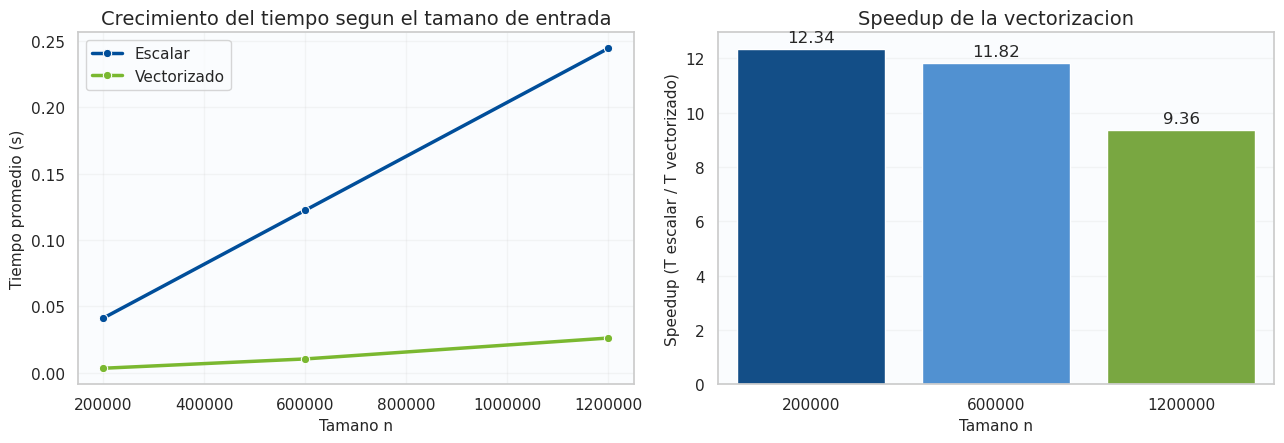

In [3]:
ex1_sizes = [200_000, 600_000, 1_200_000]
ex1_arrays = {n: np.linspace(1 / n, 1.0, n, dtype=np.float64) for n in ex1_sizes}
ex1_lists = {n: ex1_arrays[n].tolist() for n in ex1_sizes}


def scalar_signal_transform(values):
    total = 0.0
    for value in values:
        total += math.sqrt(value + 1e-6) + math.log1p(value) + math.sin(value) ** 2
    return total


def vector_signal_transform(values):
    return np.sqrt(values + 1e-6).sum() + np.log1p(values).sum() + np.square(np.sin(values)).sum()


ex1_rows = []
ex1_max_diff = 0.0

for n in ex1_sizes:
    scalar_stats = benchmark(lambda n=n: scalar_signal_transform(ex1_lists[n]))
    vector_stats = benchmark(lambda n=n: vector_signal_transform(ex1_arrays[n]))
    speedup = scalar_stats["mean_s"] / vector_stats["mean_s"]
    diff = abs(scalar_stats["result"] - vector_stats["result"])
    ex1_max_diff = max(ex1_max_diff, diff)
    ex1_rows.append(
        {
            "n": n,
            "Tiempo escalar (s)": scalar_stats["mean_s"],
            "Desv. escalar (s)": scalar_stats["std_s"],
            "Tiempo vectorizado (s)": vector_stats["mean_s"],
            "Desv. vectorizado (s)": vector_stats["std_s"],
            "Speedup": speedup,
        }
    )

ex1_df = pd.DataFrame(ex1_rows)
show_df(
    ex1_df,
    "Ejercicio 1 - Tiempos promedio y speedup de la version vectorizada",
    formats={
        "n": fmt_int,
        "Tiempo escalar (s)": "{:.4f}",
        "Desv. escalar (s)": "{:.4f}",
        "Tiempo vectorizado (s)": "{:.4f}",
        "Desv. vectorizado (s)": "{:.4f}",
        "Speedup": "{:.2f}",
    },
    gradient_cols=["Tiempo escalar (s)", "Tiempo vectorizado (s)", "Speedup"],
)

best_ex1 = ex1_df.loc[ex1_df["Speedup"].idxmax()]
metric_cards(
    [
        ("Mejor speedup", fmt_ratio(best_ex1["Speedup"]), f"n = {fmt_int(best_ex1['n'])}", "#004E9A"),
        ("Diferencia numerica maxima", f"{ex1_max_diff:.2e}", "Las dos versiones son equivalentes", "#7AB830"),
        ("Patron observado", "SIMD implicito", "NumPy reduce el overhead del interprete", "#113A5C"),
    ]
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
sns.lineplot(data=ex1_df, x="n", y="Tiempo escalar (s)", marker="o", linewidth=2.5, ax=axes[0], label="Escalar")
sns.lineplot(data=ex1_df, x="n", y="Tiempo vectorizado (s)", marker="o", linewidth=2.5, ax=axes[0], label="Vectorizado")
axes[0].set_title("Crecimiento del tiempo segun el tamano de entrada")
axes[0].set_xlabel("Tamano n")
axes[0].set_ylabel("Tiempo promedio (s)")
axes[0].ticklabel_format(style="plain", axis="x")

sns.barplot(
    data=ex1_df,
    x="n",
    y="Speedup",
    hue="n",
    dodge=False,
    legend=False,
    palette=["#004E9A", "#3C91E6", "#7AB830"],
    ax=axes[1],
)
axes[1].set_title("Speedup de la vectorizacion")
axes[1].set_xlabel("Tamano n")
axes[1].set_ylabel("Speedup (T escalar / T vectorizado)")
for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%.2f", padding=3)

plt.tight_layout()
plt.show()

In [4]:
ex1_mean_speedup = ex1_df["Speedup"].mean()
display(
    Markdown(
        f"""
        ### Interpretacion del Ejercicio 1

        La version vectorizada logro un speedup promedio de **{ex1_mean_speedup:.2f}x** y alcanzo su mejor punto en
        **n = {fmt_int(best_ex1['n'])}** con **{best_ex1['Speedup']:.2f}x**. Este resultado cumple exactamente la idea del
        laboratorio: **hay mejora real de tiempo, pero no porque hayamos distribuido tareas entre procesos**, sino porque
        NumPy ejecuta la operacion en codigo compilado, aprovecha procesamiento vectorial y elimina gran parte del overhead del
        bucle Python.

        Desde la taxonomia vista en clase, este comportamiento se parece mas a **paralelismo de datos/SIMD** que a MIMD.
        La interpretacion correcta es que la vectorizacion puede entregar un "speedup" muy alto aun cuando el programador no
        escribe hilos ni procesos. Por eso, antes de paralelizar una carga numerica, conviene preguntar primero si el problema
        puede reformularse como una operacion vectorizada.
        """
    )
)


        ### Interpretacion del Ejercicio 1

        La version vectorizada logro un speedup promedio de **11.17x** y alcanzo su mejor punto en
        **n = 200.000** con **12.34x**. Este resultado cumple exactamente la idea del
        laboratorio: **hay mejora real de tiempo, pero no porque hayamos distribuido tareas entre procesos**, sino porque
        NumPy ejecuta la operacion en codigo compilado, aprovecha procesamiento vectorial y elimina gran parte del overhead del
        bucle Python.

        Desde la taxonomia vista en clase, este comportamiento se parece mas a **paralelismo de datos/SIMD** que a MIMD.
        La interpretacion correcta es que la vectorizacion puede entregar un "speedup" muy alto aun cuando el programador no
        escribe hilos ni procesos. Por eso, antes de paralelizar una carga numerica, conviene preguntar primero si el problema
        puede reformularse como una operacion vectorizada.
        

## Ejercicio 2 - Paralelismo practico y limitaciones

En este bloque se comparan dos escenarios deliberadamente distintos:

- **2.a:** trabajo dominado por espera y latencia, donde los hilos deberian solaparse bien;
- **2.b:** trabajo CPU-bound puro, donde los procesos deberian superar a los hilos debido al GIL.

### 2.a - Consultas de metadatos con latencia simulada

**Propuesta original:** cada tarea representa la lectura de un encabezado de archivo o consulta corta a un servicio,
con una pausa artificial y una pequena verificacion de integridad. Es un caso de **paralelismo de tareas** en memoria compartida.

Hilos,Tiempo medio (s),Desv. (s),Speedup,Eficiencia
1,0.7120,0.0012,1.00,0.999
2,0.3803,0.0012,1.87,0.935
4,0.1977,0.0008,3.60,0.899
8,0.1101,0.0005,6.46,0.808


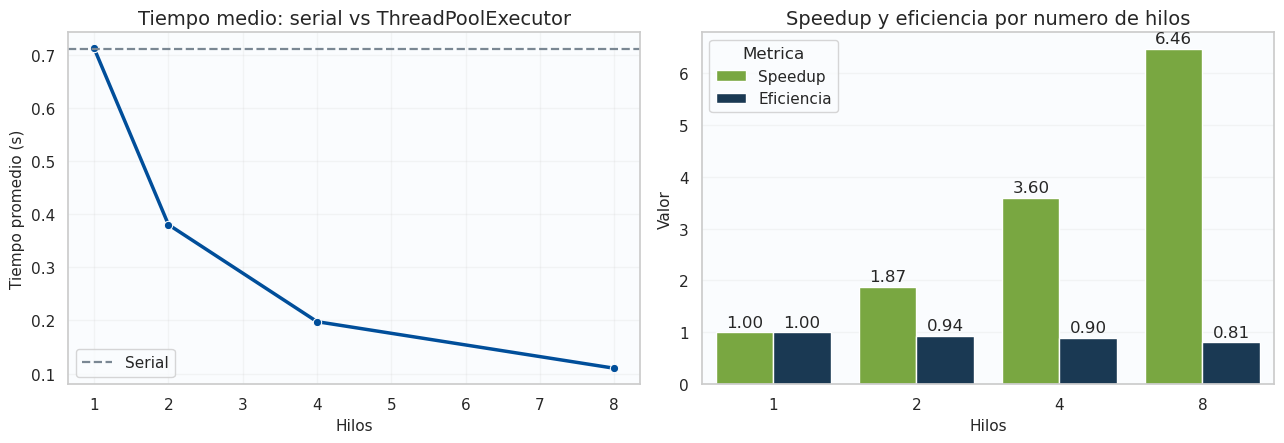

In [5]:
ex2a_tasks = list(range(16))


def fetch_metadata(task_id):
    time.sleep(0.035 + (task_id % 4) * 0.006)
    payload = f"sensor-{task_id:02d}|telemetria|calidad".encode("utf-8")
    digest = hashlib.blake2b(payload, digest_size=16).hexdigest()
    checksum = sum(int(char, 16) for char in digest)
    return task_id, checksum


def run_metadata_serial():
    return [fetch_metadata(task_id) for task_id in ex2a_tasks]


def run_metadata_threads(workers):
    with ThreadPoolExecutor(max_workers=workers) as executor:
        return list(executor.map(fetch_metadata, ex2a_tasks))


ex2a_serial_stats = benchmark(run_metadata_serial)
ex2a_serial_time = ex2a_serial_stats["mean_s"]
ex2a_reference = ex2a_serial_stats["result"]
ex2a_rows = []

for workers in [1, 2, 4, 8]:
    stats = benchmark(lambda workers=workers: run_metadata_threads(workers))
    assert stats["result"] == ex2a_reference
    speedup = ex2a_serial_time / stats["mean_s"]
    efficiency = speedup / workers
    ex2a_rows.append(
        {
            "Hilos": workers,
            "Tiempo medio (s)": stats["mean_s"],
            "Desv. (s)": stats["std_s"],
            "Speedup": speedup,
            "Eficiencia": efficiency,
        }
    )

ex2a_df = pd.DataFrame(ex2a_rows)

metric_cards(
    [
        ("Referencia serial", fmt_seconds(ex2a_serial_time), "Misma carga sin hilos", "#113A5C"),
        (
            "Mejor tiempo con hilos",
            fmt_seconds(ex2a_df["Tiempo medio (s)"].min()),
            f"Configuracion optima: {int(ex2a_df.loc[ex2a_df['Tiempo medio (s)'].idxmin(), 'Hilos'])} hilos",
            "#004E9A",
        ),
        (
            "Mejor speedup",
            fmt_ratio(ex2a_df["Speedup"].max()),
            "El trabajo de espera se solapa correctamente",
            "#7AB830",
        ),
    ]
)

show_df(
    ex2a_df,
    "Ejercicio 2.a - Hilos sobre una carga dominada por latencia",
    formats={
        "Hilos": "{:.0f}",
        "Tiempo medio (s)": "{:.4f}",
        "Desv. (s)": "{:.4f}",
        "Speedup": "{:.2f}",
        "Eficiencia": "{:.3f}",
    },
    gradient_cols=["Tiempo medio (s)", "Speedup", "Eficiencia"],
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
sns.lineplot(data=ex2a_df, x="Hilos", y="Tiempo medio (s)", marker="o", linewidth=2.5, ax=axes[0], color="#004E9A")
axes[0].axhline(ex2a_serial_time, linestyle="--", linewidth=1.6, color="#7A8793", label="Serial")
axes[0].legend()
axes[0].set_title("Tiempo medio: serial vs ThreadPoolExecutor")
axes[0].set_ylabel("Tiempo promedio (s)")

ex2a_plot = ex2a_df.melt(id_vars="Hilos", value_vars=["Speedup", "Eficiencia"], var_name="Metrica", value_name="Valor")
sns.barplot(data=ex2a_plot, x="Hilos", y="Valor", hue="Metrica", palette=["#7AB830", "#113A5C"], ax=axes[1])
axes[1].set_title("Speedup y eficiencia por numero de hilos")
axes[1].set_ylabel("Valor")
for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%.2f", padding=2)

plt.tight_layout()
plt.show()

In [6]:
best_ex2a = ex2a_df.loc[ex2a_df["Tiempo medio (s)"].idxmin()]
display(
    Markdown(
        f"""
        ### Interpretacion del Ejercicio 2.a

        La carga fue construida para parecerse a una consulta breve de metadatos: cada tarea tiene una espera dominante y una
        comprobacion ligera. En este contexto, los hilos funcionan bien porque **el tiempo no se va en computo intenso**, sino en
        periodos de espera que pueden solaparse. La mejor configuracion fue **{int(best_ex2a['Hilos'])} hilos**, con un tiempo medio
        de **{best_ex2a['Tiempo medio (s)']:.4f} s**, speedup de **{best_ex2a['Speedup']:.2f}x** y eficiencia de
        **{best_ex2a['Eficiencia'] * 100:.1f}%**.

        Este comportamiento es consistente con el modelo de **memoria compartida** y con **paralelismo de tareas**: las unidades
        de trabajo son independientes, el estado compartido es minimo y la coordinacion es barata. A la vez, el resultado muestra
        una leccion importante del laboratorio: **el paralelismo correcto depende del tipo de carga**. Para latencia e I/O leve,
        ThreadPoolExecutor es una opcion natural y no hay necesidad de pasar a procesos.
        """
    )
)


        ### Interpretacion del Ejercicio 2.a

        La carga fue construida para parecerse a una consulta breve de metadatos: cada tarea tiene una espera dominante y una
        comprobacion ligera. En este contexto, los hilos funcionan bien porque **el tiempo no se va en computo intenso**, sino en
        periodos de espera que pueden solaparse. La mejor configuracion fue **8 hilos**, con un tiempo medio
        de **0.1101 s**, speedup de **6.46x** y eficiencia de
        **80.8%**.

        Este comportamiento es consistente con el modelo de **memoria compartida** y con **paralelismo de tareas**: las unidades
        de trabajo son independientes, el estado compartido es minimo y la coordinacion es barata. A la vez, el resultado muestra
        una leccion importante del laboratorio: **el paralelismo correcto depende del tipo de carga**. Para latencia e I/O leve,
        ThreadPoolExecutor es una opcion natural y no hay necesidad de pasar a procesos.
        

### 2.b - Estimacion paralela de PI con Monte Carlo

**Propuesta original:** calcular PI mediante bloques independientes de simulacion aleatoria. Cada bloque usa una semilla distinta
y cuenta cuantos puntos caen dentro del circulo unitario. Es un caso clasico de **CPU-bound** y paralelismo de tareas independiente.

Procesos,Tiempo medio (s),Desv. (s),Speedup,Eficiencia,PI estimado
2,0.5325,0.0043,1.54,0.768,3.14211
4,0.3417,0.0077,2.39,0.599,3.14211
8,0.2841,0.0080,2.88,0.360,3.14211


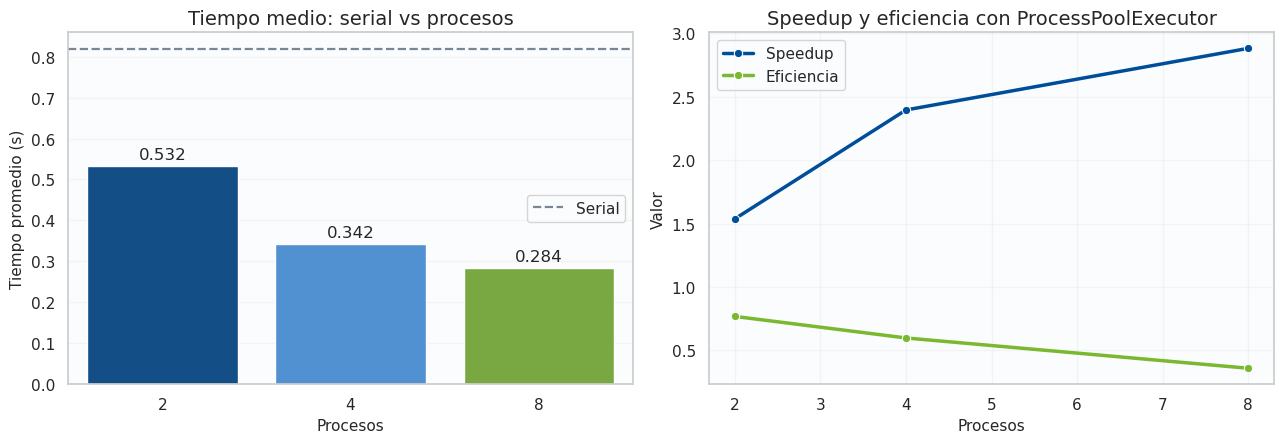

In [7]:
ex2b_chunks = [(300 + idx, 600_000) for idx in range(8)]
ex2b_total_samples = sum(samples for _, samples in ex2b_chunks)


def run_pi_serial():
    return [monte_carlo_pi_chunk(chunk) for chunk in ex2b_chunks]


def run_pi_processes(workers):
    return run_process_map(monte_carlo_pi_chunk, ex2b_chunks, workers)


ex2b_serial_stats = benchmark(run_pi_serial)
ex2b_serial_inside = sum(ex2b_serial_stats["result"])
ex2b_serial_pi = 4 * ex2b_serial_inside / ex2b_total_samples
ex2b_rows = []

for workers in [2, 4, 8]:
    stats = benchmark(lambda workers=workers: run_pi_processes(workers))
    inside = sum(stats["result"])
    pi_estimate = 4 * inside / ex2b_total_samples
    speedup = ex2b_serial_stats["mean_s"] / stats["mean_s"]
    efficiency = speedup / workers
    ex2b_rows.append(
        {
            "Procesos": workers,
            "Tiempo medio (s)": stats["mean_s"],
            "Desv. (s)": stats["std_s"],
            "Speedup": speedup,
            "Eficiencia": efficiency,
            "PI estimado": pi_estimate,
        }
    )

ex2b_df = pd.DataFrame(ex2b_rows)

metric_cards(
    [
        ("Tiempo secuencial", fmt_seconds(ex2b_serial_stats["mean_s"]), "Misma simulacion con un solo flujo", "#113A5C"),
        ("PI estimado", f"{ex2b_serial_pi:.5f}", "Referencia numerica del experimento", "#004E9A"),
        ("Mejor speedup", fmt_ratio(ex2b_df["Speedup"].max()), "Procesos liberan la restriccion del GIL", "#7AB830"),
    ]
)

show_df(
    ex2b_df,
    "Ejercicio 2.b - Pool de procesos sobre una carga CPU-bound",
    formats={
        "Procesos": "{:.0f}",
        "Tiempo medio (s)": "{:.4f}",
        "Desv. (s)": "{:.4f}",
        "Speedup": "{:.2f}",
        "Eficiencia": "{:.3f}",
        "PI estimado": "{:.5f}",
    },
    gradient_cols=["Tiempo medio (s)", "Speedup", "Eficiencia"],
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
sns.barplot(
    data=ex2b_df,
    x="Procesos",
    y="Tiempo medio (s)",
    hue="Procesos",
    dodge=False,
    legend=False,
    palette=["#004E9A", "#3C91E6", "#7AB830"],
    ax=axes[0],
)
axes[0].axhline(ex2b_serial_stats["mean_s"], linestyle="--", linewidth=1.6, color="#7A8793", label="Serial")
axes[0].legend()
axes[0].set_title("Tiempo medio: serial vs procesos")
axes[0].set_ylabel("Tiempo promedio (s)")
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.3f", padding=3)

ex2b_plot = ex2b_df.melt(id_vars="Procesos", value_vars=["Speedup", "Eficiencia"], var_name="Metrica", value_name="Valor")
sns.lineplot(data=ex2b_plot, x="Procesos", y="Valor", hue="Metrica", marker="o", linewidth=2.5, ax=axes[1])
axes[1].set_title("Speedup y eficiencia con ProcessPoolExecutor")
axes[1].set_ylabel("Valor")
axes[1].legend(title="")

plt.tight_layout()
plt.show()

In [8]:
best_ex2b = ex2b_df.loc[ex2b_df["Tiempo medio (s)"].idxmin()]
display(
    Markdown(
        f"""
        ### Interpretacion del Ejercicio 2.b

        Aqui el comportamiento cambia por completo respecto del inciso anterior. La simulacion Monte Carlo es **CPU-bound** y
        cada bloque consume computo puro. En este escenario, los procesos son la estrategia correcta porque cada worker ejecuta en
        su propio interprete y evita la limitacion del **GIL**. La mejor configuracion fue **{int(best_ex2b['Procesos'])} procesos**,
        con un tiempo medio de **{best_ex2b['Tiempo medio (s)']:.4f} s**, speedup de **{best_ex2b['Speedup']:.2f}x** y eficiencia
        de **{best_ex2b['Eficiencia'] * 100:.1f}%**.

        El speedup es claramente sublineal, lo que es esperable por costos de creacion de procesos, serializacion y coordinacion.
        Eso conecta con la Ley de Amdahl: aunque la tarea sea muy paralelizable, el overhead impide alcanzar el ideal `S(p)=p`.
        Aun asi, la mejora es lo bastante solida como para justificar procesos cuando el trabajo por bloque es suficientemente pesado.
        """
    )
)


        ### Interpretacion del Ejercicio 2.b

        Aqui el comportamiento cambia por completo respecto del inciso anterior. La simulacion Monte Carlo es **CPU-bound** y
        cada bloque consume computo puro. En este escenario, los procesos son la estrategia correcta porque cada worker ejecuta en
        su propio interprete y evita la limitacion del **GIL**. La mejor configuracion fue **8 procesos**,
        con un tiempo medio de **0.2841 s**, speedup de **2.88x** y eficiencia
        de **36.0%**.

        El speedup es claramente sublineal, lo que es esperable por costos de creacion de procesos, serializacion y coordinacion.
        Eso conecta con la Ley de Amdahl: aunque la tarea sea muy paralelizable, el overhead impide alcanzar el ideal `S(p)=p`.
        Aun asi, la mejora es lo bastante solida como para justificar procesos cuando el trabajo por bloque es suficientemente pesado.
        

## Ejercicio 3 - Decision estrategica sobre lotes independientes

**Propuesta original:** simular archivos o lotes independientes de telemetria y extraer dos indicadores sinteticos por lote.
El interes no esta solo en medir el tiempo, sino en responder con evidencia si conviene:

- seguir secuencial;
- escalar verticalmente dentro del mismo equipo;
- o pasar a una estrategia horizontal/distribuida.

Lote,Puntaje espectral,Volatilidad
1,60.7169,14.5379
2,60.4756,14.5297
3,60.6344,14.5359
4,60.7544,14.5328
5,60.6348,14.5072
6,60.5004,14.5226


Procesos,Tiempo medio (s),Desv. (s),Speedup,Eficiencia,Suma espectral,Suma volatilidad
2,0.5093,0.0077,1.51,0.753,605.6416,145.1745
4,0.3594,0.0039,2.13,0.533,605.6416,145.1745
8,0.3094,0.0020,2.48,0.310,605.6416,145.1745


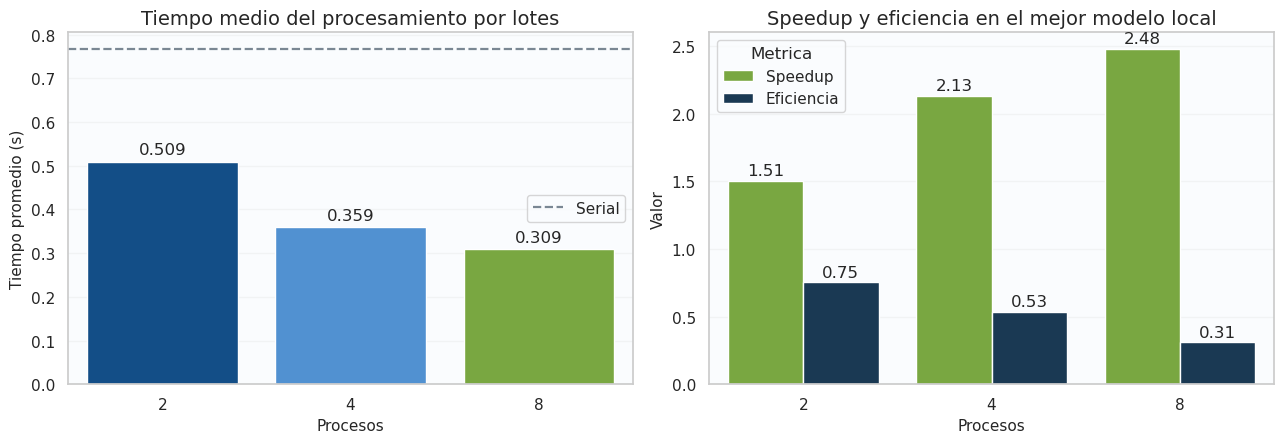

In [9]:
ex3_tasks = [(batch_id, 800 + batch_id, 160_000) for batch_id in range(1, 11)]


def run_batches_serial():
    return [extract_batch_profile(task) for task in ex3_tasks]


def run_batches_processes(workers):
    return run_process_map(extract_batch_profile, ex3_tasks, workers)


ex3_serial_stats = benchmark(run_batches_serial)
ex3_profiles = sorted(ex3_serial_stats["result"])
ex3_profiles_df = pd.DataFrame(ex3_profiles, columns=["Lote", "Puntaje espectral", "Volatilidad"])
show_df(
    ex3_profiles_df.head(6),
    "Muestra de perfiles extraidos por lote (resultado secuencial)",
    formats={
        "Lote": "{:.0f}",
        "Puntaje espectral": "{:.4f}",
        "Volatilidad": "{:.4f}",
    },
    gradient_cols=["Puntaje espectral", "Volatilidad"],
)

ex3_rows = []
for workers in [2, 4, 8]:
    stats = benchmark(lambda workers=workers: run_batches_processes(workers))
    result_sorted = sorted(stats["result"])
    spectral_total = sum(row[1] for row in result_sorted)
    volatility_total = sum(row[2] for row in result_sorted)
    speedup = ex3_serial_stats["mean_s"] / stats["mean_s"]
    efficiency = speedup / workers
    ex3_rows.append(
        {
            "Procesos": workers,
            "Tiempo medio (s)": stats["mean_s"],
            "Desv. (s)": stats["std_s"],
            "Speedup": speedup,
            "Eficiencia": efficiency,
            "Suma espectral": spectral_total,
            "Suma volatilidad": volatility_total,
        }
    )

ex3_df = pd.DataFrame(ex3_rows)

metric_cards(
    [
        ("Tiempo secuencial", fmt_seconds(ex3_serial_stats["mean_s"]), "Procesamiento lote a lote", "#113A5C"),
        (
            "Mejor tiempo paralelo",
            fmt_seconds(ex3_df["Tiempo medio (s)"].min()),
            f"Mejor configuracion: {int(ex3_df.loc[ex3_df['Tiempo medio (s)'].idxmin(), 'Procesos'])} procesos",
            "#004E9A",
        ),
        ("Mejor speedup", fmt_ratio(ex3_df["Speedup"].max()), "Medida para decidir la estrategia", "#7AB830"),
    ]
)

show_df(
    ex3_df,
    "Ejercicio 3 - Procesamiento por lotes y comparacion de configuraciones",
    formats={
        "Procesos": "{:.0f}",
        "Tiempo medio (s)": "{:.4f}",
        "Desv. (s)": "{:.4f}",
        "Speedup": "{:.2f}",
        "Eficiencia": "{:.3f}",
        "Suma espectral": "{:.4f}",
        "Suma volatilidad": "{:.4f}",
    },
    gradient_cols=["Tiempo medio (s)", "Speedup", "Eficiencia"],
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
sns.barplot(
    data=ex3_df,
    x="Procesos",
    y="Tiempo medio (s)",
    hue="Procesos",
    dodge=False,
    legend=False,
    palette=["#004E9A", "#3C91E6", "#7AB830"],
    ax=axes[0],
)
axes[0].axhline(ex3_serial_stats["mean_s"], linestyle="--", linewidth=1.6, color="#7A8793", label="Serial")
axes[0].legend()
axes[0].set_title("Tiempo medio del procesamiento por lotes")
axes[0].set_ylabel("Tiempo promedio (s)")
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.3f", padding=3)

ex3_plot = ex3_df.melt(id_vars="Procesos", value_vars=["Speedup", "Eficiencia"], var_name="Metrica", value_name="Valor")
sns.barplot(data=ex3_plot, x="Procesos", y="Valor", hue="Metrica", palette=["#7AB830", "#113A5C"], ax=axes[1])
axes[1].set_title("Speedup y eficiencia en el mejor modelo local")
axes[1].set_ylabel("Valor")
for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%.2f", padding=2)

plt.tight_layout()
plt.show()

In [10]:
best_ex3 = ex3_df.loc[ex3_df["Tiempo medio (s)"].idxmin()]
recommendation_text = f"""
### Diagnostico y recomendacion tecnica

La evidencia experimental favorece **escalar verticalmente dentro del mismo equipo**. El problema esta compuesto por lotes
independientes y la coordinacion entre ellos es minima: cada worker procesa su lote, retorna dos metricas agregadas y la
combinacion final es barata. Con **{int(best_ex3['Procesos'])} procesos** se obtuvo el mejor tiempo medio
(**{best_ex3['Tiempo medio (s)']:.4f} s**), con speedup de **{best_ex3['Speedup']:.2f}x** y eficiencia de
**{best_ex3['Eficiencia'] * 100:.1f}%**.

Quedarse secuencial no parece la mejor decision porque la mejora paralela es clara y estable. Tampoco hay senales de que hoy
haga falta escalar horizontalmente: el volumen cabe bien en un solo equipo, la memoria no es un cuello de botella y distribuir
la carga agregaria costos de comunicacion y orquestacion que este caso todavia no justifica. La recomendacion, por tanto, es
**paralelismo local con procesos** como primera opcion, dejando la computacion distribuida para un escenario con muchos mas lotes,
mayor volumen por lote o necesidad de repartir datos entre nodos.
"""
display(Markdown(recommendation_text))


### Diagnostico y recomendacion tecnica

La evidencia experimental favorece **escalar verticalmente dentro del mismo equipo**. El problema esta compuesto por lotes
independientes y la coordinacion entre ellos es minima: cada worker procesa su lote, retorna dos metricas agregadas y la
combinacion final es barata. Con **8 procesos** se obtuvo el mejor tiempo medio
(**0.3094 s**), con speedup de **2.48x** y eficiencia de
**31.0%**.

Quedarse secuencial no parece la mejor decision porque la mejora paralela es clara y estable. Tampoco hay senales de que hoy
haga falta escalar horizontalmente: el volumen cabe bien en un solo equipo, la memoria no es un cuello de botella y distribuir
la carga agregaria costos de comunicacion y orquestacion que este caso todavia no justifica. La recomendacion, por tanto, es
**paralelismo local con procesos** como primera opcion, dejando la computacion distribuida para un escenario con muchos mas lotes,
mayor volumen por lote o necesidad de repartir datos entre nodos.


In [11]:
reflection_text = f"""
## Reflexion diagnostica final

Para decidir si conviene paralelizar una aplicacion de ciencia de datos, usaria siempre una combinacion de criterios
**cuantitativos** y **cualitativos**. En lo cuantitativo, partiria por medir una version secuencial confiable y luego calcularia
`speedup` y `eficiencia` para distintas configuraciones. En este notebook aparecieron tres patrones utiles: la vectorizacion de
NumPy consiguio un speedup promedio de **{ex1_df['Speedup'].mean():.2f}x** sin recurrir a procesos; los hilos funcionaron muy bien
en una carga dominada por latencia; y los procesos fueron la mejor opcion cuando el trabajo fue realmente CPU-bound. Eso confirma
que mirar solo el tiempo total no basta: hay que entender **donde** se consume ese tiempo.

En lo cualitativo, observaria independencia entre tareas, volumen de datos, costo de comunicacion, necesidad de sincronizacion y
facilidad de particionamiento. Si las unidades de trabajo son independientes y el overhead de coordinarlas es bajo, el
paralelismo tiene sentido. Si la ganancia principal viene de reformular el calculo como operacion vectorizada, primero optaria por
esa via. Si en cambio aparecen procesos pesados y repetibles, privilegiaria procesos locales; y solo pensaria en computacion
distribuida cuando el tamano del problema o la memoria requerida ya superen lo razonable para un solo equipo.

En sintesis, paralelizar no es una decision ideologica, sino una decision tecnica basada en mediciones equivalentes, estructura
del problema y costo real de coordinacion.
"""
display(Markdown(reflection_text))


## Reflexion diagnostica final

Para decidir si conviene paralelizar una aplicacion de ciencia de datos, usaria siempre una combinacion de criterios
**cuantitativos** y **cualitativos**. En lo cuantitativo, partiria por medir una version secuencial confiable y luego calcularia
`speedup` y `eficiencia` para distintas configuraciones. En este notebook aparecieron tres patrones utiles: la vectorizacion de
NumPy consiguio un speedup promedio de **11.17x** sin recurrir a procesos; los hilos funcionaron muy bien
en una carga dominada por latencia; y los procesos fueron la mejor opcion cuando el trabajo fue realmente CPU-bound. Eso confirma
que mirar solo el tiempo total no basta: hay que entender **donde** se consume ese tiempo.

En lo cualitativo, observaria independencia entre tareas, volumen de datos, costo de comunicacion, necesidad de sincronizacion y
facilidad de particionamiento. Si las unidades de trabajo son independientes y el overhead de coordinarlas es bajo, el
paralelismo tiene sentido. Si la ganancia principal viene de reformular el calculo como operacion vectorizada, primero optaria por
esa via. Si en cambio aparecen procesos pesados y repetibles, privilegiaria procesos locales; y solo pensaria en computacion
distribuida cuando el tamano del problema o la memoria requerida ya superen lo razonable para un solo equipo.

En sintesis, paralelizar no es una decision ideologica, sino una decision tecnica basada en mediciones equivalentes, estructura
del problema y costo real de coordinacion.


In [12]:
summary_payload = {
    "metadata": {
        "os": platform.platform(),
        "python": platform.python_version(),
        "logical_cpus": os.cpu_count(),
        "ram_gb": round(psutil.virtual_memory().total / 1024**3, 2) if psutil else None,
    },
    "ex1": {
        "rows": to_json_records(ex1_df),
        "best_speedup": float(ex1_df["Speedup"].max()),
        "best_n": int(best_ex1["n"]),
        "avg_speedup": float(ex1_df["Speedup"].mean()),
    },
    "ex2a": {
        "serial_time": float(ex2a_serial_time),
        "rows": to_json_records(ex2a_df),
        "best_threads": int(best_ex2a["Hilos"]),
        "best_time": float(best_ex2a["Tiempo medio (s)"]),
        "best_speedup": float(best_ex2a["Speedup"]),
        "best_efficiency": float(best_ex2a["Eficiencia"]),
    },
    "ex2b": {
        "serial_time": float(ex2b_serial_stats["mean_s"]),
        "serial_pi": float(ex2b_serial_pi),
        "rows": to_json_records(ex2b_df),
        "best_processes": int(best_ex2b["Procesos"]),
        "best_time": float(best_ex2b["Tiempo medio (s)"]),
        "best_speedup": float(best_ex2b["Speedup"]),
        "best_efficiency": float(best_ex2b["Eficiencia"]),
    },
    "ex3": {
        "serial_time": float(ex3_serial_stats["mean_s"]),
        "rows": to_json_records(ex3_df),
        "best_processes": int(best_ex3["Procesos"]),
        "best_time": float(best_ex3["Tiempo medio (s)"]),
        "best_speedup": float(best_ex3["Speedup"]),
        "best_efficiency": float(best_ex3["Eficiencia"]),
    },
}

with SUMMARY_PATH.open("w", encoding="utf-8") as summary_file:
    json.dump(summary_payload, summary_file, indent=2)

callout(
    "Exportacion interna completada",
    f"Se genero el archivo de resumen en <code>{SUMMARY_PATH.name}</code> para construir automaticamente el guion de presentacion.",
    accent="#004E9A",
    bg="#F5F9FE",
)